<a href="https://colab.research.google.com/github/Kamala-Juvvala/Predictive_Analytics/blob/Product_Recommendation_System/Product_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905       26.1415     9.1  
1  10:

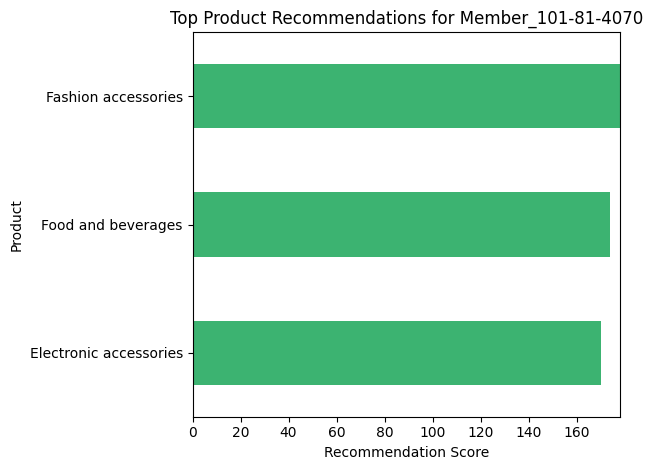

In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# STEP 1: Load and preview the data
df = pd.read_csv('supermarket_sales - Sheet1.csv')
print(df.head())

# STEP 2: Create a Customer × Product Matrix (binary: 1 = bought)
# We'll use 'Customer type' + 'Invoice ID' as a proxy for unique customers if Customer ID is missing
df['Customer'] = df['Customer type'] + "_" + df['Invoice ID']

# Use 'Product line' as the product
purchase_matrix = df.pivot_table(index='Customer', columns='Product line', values='Quantity', aggfunc='sum', fill_value=0)

# Convert to binary: 1 if customer bought the product
purchase_matrix_binary = (purchase_matrix > 0).astype(int)

# STEP 3: Compute Customer Similarity
similarity = cosine_similarity(purchase_matrix_binary)
similarity_df = pd.DataFrame(similarity, index=purchase_matrix_binary.index, columns=purchase_matrix_binary.index)

# STEP 4: Recommend Products Based on Similar Customers
def recommend_next_products(customer_id, top_n_similar=5, top_n_products=3, similarity_threshold=0.1):
    if customer_id not in purchase_matrix_binary.index:
        return f"Customer {customer_id} not found in data."

    # STEP 1: Get similarity scores (excluding self)
    sim_scores = similarity_df[customer_id].drop(customer_id)

    # STEP 2: Filter only customers with meaningful similarity
    top_sim_customers = sim_scores[sim_scores > similarity_threshold].sort_values(ascending=False).head(top_n_similar).index

    # STEP 3: Get products not bought by target customer
    customer_products = purchase_matrix_binary.loc[customer_id]
    unbought = customer_products[customer_products == 0].index

    if top_sim_customers.empty or unbought.empty:
        return pd.Series(dtype=float)

    # STEP 4: Calculate average purchase rate among similar users
    similar_purchases = purchase_matrix_binary.loc[top_sim_customers, unbought]
    scores = similar_purchases.mean().sort_values(ascending=False)

    # STEP 5: Fallback to most popular products overall if no scores found
    if scores.empty or (scores == 0).all():
        fallback = purchase_matrix_binary[unbought].sum().sort_values(ascending=False).head(top_n_products)
        print(f"No strong signal from similar customers. Showing most popular instead.")
        return fallback

    return scores.head(top_n_products)
# STEP 5: Try recommendation and visualize
target_customer = purchase_matrix_binary.index[0]  # pick a customer from data
recommendations = recommend_next_products(target_customer)

# Print and plot recommendations
print(f"\n🛒 Recommended products for {target_customer}:\n", recommendations)

recommendations = recommend_next_products(target_customer)

# Only plot if we have something to show
if not recommendations.empty:
    recommendations.plot(kind='barh', color='mediumseagreen')
    plt.title(f"Top Product Recommendations for {target_customer}")
    plt.xlabel("Recommendation Score")
    plt.ylabel("Product")
    plt.xlim(0, recommendations.max() + 0.1)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No recommendations available for this customer.")
